使用Scikit_Learn进行线型回归

In [1]:
""" 
1,导包
"""

import numpy as np
np.set_printoptions(precision=2)
import matplotlib.pyplot as plt
from lab_utils_multi import  load_house_data
dlblue = '#0096ff'; dlorange = '#FF9300'; dldarkred='#C00000'; dlmagenta='#FF40FF'; dlpurple='#7030A0'; 
plt.style.use('./deeplearning.mplstyle')

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler

In [8]:
""" 
2梯度下降,Scikit-learn有一个梯度下降回归模型

2.1加载数据集
"""
X_train, y_train = load_house_data()
X_features = ['size','bedroom','floors','age']

""" 
2.2缩放/归一化训练数据
"""
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
print(np.ptp(X_train,axis=0))   
print(np.ptp(X_norm,axis=0)) #归一化后的数据

[2.41e+03 4.00e+00 1.00e+00 9.50e+01]
[5.85 6.14 2.06 3.69]


In [9]:

""" 
2.3创建并拟合回归模型
"""
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 103, number of weight updates: 10198.0


In [10]:
""" 
2.4查看参数
"""
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")
print(f"model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16")

model parameters:                   w: [109.68 -20.89 -32.25 -38.12], b:[363.15]
model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16


In [11]:
""" 
2.5进行预测
"""

y_pred_sgd = sgdr.predict(X_norm)
y_pred = np.dot(X_norm, w_norm) + b_norm  
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")
print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[295.2  485.72 389.59 491.88]
Target values 
[300.  509.8 394.  540. ]


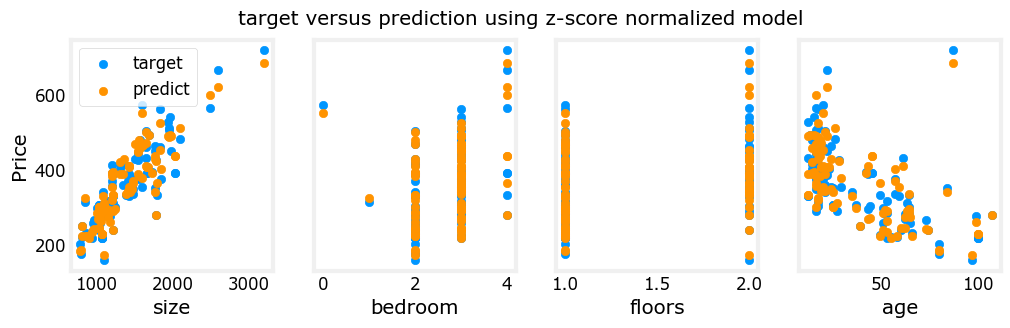

In [12]:
""" 
2.6绘图结果
"""  
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],y_pred,color=dlorange, label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()